Today's date: 2026-03-06

Latest SET index:
         date  setindex
0  2026-02-27   1528.26

First SET index of 2026:
         date  setindex
0  2026-01-05   1280.05

SET index change: 248.21 points (19.39%)
Period: 2026-01-05 to 2026-02-27

Active buy orders:


period,name,shares
1,PTTGC,6000
1,SCC,600
1,SINGER,6000
1,STA,10000
2,3BBIF,120000
2,CPNREIT,55000
2,DIF,45000
2,GVREIT,69000
2,MCS,75000
2,NER,27000



Retrieved price data for 1200 records

STOCK PERFORMANCE COMPARED TO SET INDEX
Period: 2026-01-05 to 2026-02-27
SET Index Change: 19.39%

📈 STOCKS PERFORMING BETTER THAN SET:


,period,name,pct_change,set_pct_change,vs_set,current_value
26,4,IVL,41.36%,19.39%,21.97%,"164,880.00"
20,3,PTG,39.16%,19.39%,19.77%,"35,820.00"
0,1,PTTGC,33.89%,19.39%,14.50%,"169,500.00"
28,4,JMT,27.59%,19.39%,8.20%,"77,700.00"
2,1,SINGER,23.97%,19.39%,4.58%,"36,000.00"
29,4,ORI,21.59%,19.39%,2.20%,"107,000.00"



📉 STOCKS PERFORMING WORSE THAN SET:


,period,name,pct_change,set_pct_change,vs_set,current_value
16,3,AH,19.20%,19.39%,-0.19%,"17,880.00"
17,3,AWC,19.05%,19.39%,-0.34%,"22,500.00"
1,1,SCC,18.42%,19.39%,-0.97%,"135,000.00"
15,3,ADVANC,18.38%,19.39%,-1.01%,"38,000.00"
3,1,STA,16.67%,19.39%,-2.72%,"147,000.00"
10,2,PTT,16.54%,19.39%,-2.86%,"277,500.00"
8,2,MCS,14.46%,19.39%,-4.93%,"712,500.00"
27,4,JMART,12.95%,19.39%,-6.44%,"53,380.00"
13,2,WHAIR,12.90%,19.39%,-6.49%,"350,000.00"
11,2,SENA,11.11%,19.39%,-8.28%,"199,500.00"



⚖️ STOCKS PERFORMING EQUAL TO SET:
No stocks performing equal to SET

SUMMARY STATISTICS
Total Investment: 6,359,270.00
Total Current Value: 6,972,450.00
Total P&L: 613,180.00 (9.64%)
VS SET: -9.75%

Better than SET: 6 stocks
Worse than SET: 24 stocks
Equal to SET: 0 stocks


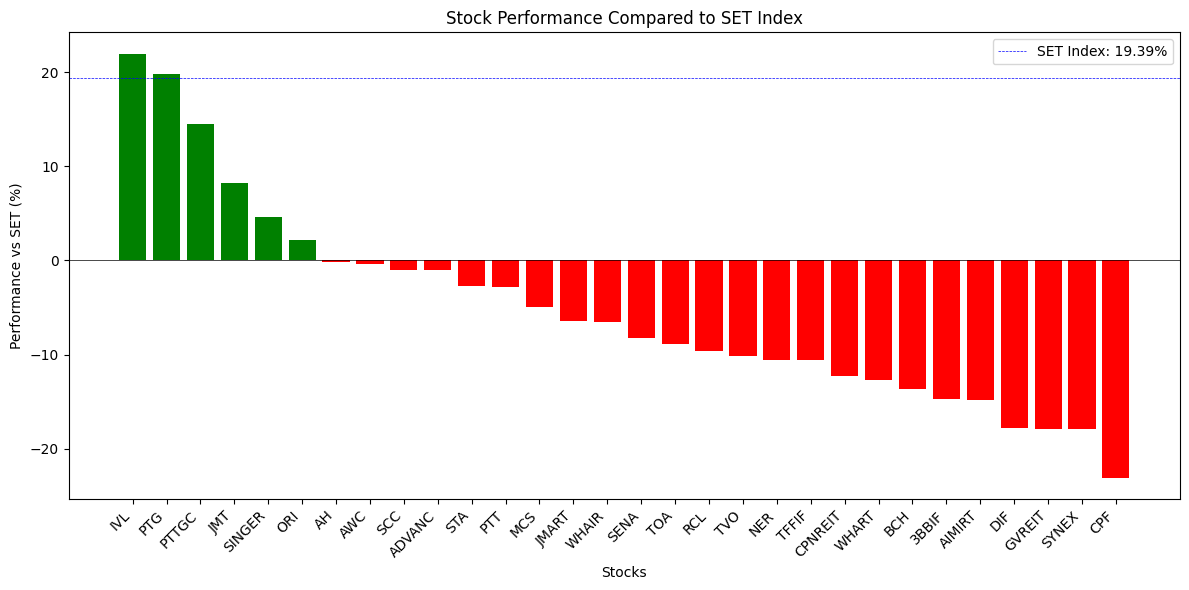


Results saved to stock_performance_vs_set_20260306.csv


In [1]:
import calendar
import os
import pandas as pd
import numpy as np
from datetime import date, timedelta
from sqlalchemy import create_engine, text
from pandas.tseries.offsets import BDay

# Database connections
engine = create_engine("mysql+pymysql://root:@localhost:3306/stock")
const = engine.connect()

pd.options.display.float_format = '{:.2f}'.format

today = date.today()
print(f"Today's date: {today}")

# Get latest SET index value
sql = "SELECT * FROM setindex ORDER BY date DESC LIMIT 1"
df_latest_set = pd.read_sql(sql, const)
print("\nLatest SET index:")
print(df_latest_set)

# Get first SET index of 2026
sql = "SELECT * FROM setindex WHERE year(date) = 2026 ORDER BY date ASC LIMIT 1"
df_first_set_2026 = pd.read_sql(sql, const)
print("\nFirst SET index of 2026:")
print(df_first_set_2026)

# Calculate SET index performance
set_diff = df_latest_set.iloc[0] - df_first_set_2026.iloc[0]
set_pct_change = ((df_latest_set['setindex'].iloc[0] - df_first_set_2026['setindex'].iloc[0]) / 
                  df_first_set_2026['setindex'].iloc[0] * 100)
print(f"\nSET index change: {set_diff['setindex']:.2f} points ({set_pct_change:.2f}%)")
print(f"Period: {df_first_set_2026['date'].iloc[0]} to {df_latest_set['date'].iloc[0]}")

# Get active buy orders
sql = '''
SELECT period, name, volbuy AS shares
FROM buy
WHERE active = 1
ORDER BY period, name
'''
df_buy = pd.read_sql(sql, const)
df_buy['shares'] = df_buy['shares'].astype('int64')
print("\nActive buy orders:")
display(df_buy.style.hide(axis="index"))

# Get price data for all stocks in the buy list
stock_list = df_buy['name'].unique().tolist()
stock_list_str = "','".join(stock_list)

# Get price data for the period
sql = f"""
SELECT name, date, price, maxp, minp, qty, opnp
FROM price 
WHERE name IN ('{stock_list_str}')
AND date BETWEEN '{df_first_set_2026['date'].iloc[0]}' AND '{df_latest_set['date'].iloc[0]}'
ORDER BY name, date
"""
df_prices = pd.read_sql(sql, const)
print(f"\nRetrieved price data for {len(df_prices)} records")

# Calculate performance for each stock
def calculate_stock_performance(df_prices, df_buy, start_date, end_date, set_pct_change):
    """
    Calculate performance metrics for each stock compared to SET index
    """
    results = []
    
    for stock in df_buy['name'].unique():
        stock_data = df_prices[df_prices['name'] == stock].copy()
        
        if len(stock_data) > 0:
            # Get first and last price in the period
            first_price = stock_data.iloc[0]['price']
            last_price = stock_data.iloc[-1]['price']
            
            # Calculate price change
            price_change = last_price - first_price
            pct_change = (price_change / first_price * 100) if first_price > 0 else 0
            
            # Compare with SET
            vs_set = pct_change - set_pct_change
            
            # Get buy information
            buy_info = df_buy[df_buy['name'] == stock].iloc[0]
            
            # Calculate current value
            current_value = last_price * buy_info['shares']
            
            results.append({
                'period': buy_info['period'],
                'name': stock,
                'shares': buy_info['shares'],
                'first_price': first_price,
                'last_price': last_price,
                'price_change': price_change,
                'pct_change': pct_change,
                'set_pct_change': set_pct_change,
                'vs_set': vs_set,
                'current_value': current_value,
                'performance': 'Better' if vs_set > 0 else 'Worse' if vs_set < 0 else 'Equal'
            })
    
    return pd.DataFrame(results)

# Calculate performance
df_performance = calculate_stock_performance(
    df_prices, 
    df_buy, 
    df_first_set_2026['date'].iloc[0], 
    df_latest_set['date'].iloc[0],
    set_pct_change
)

# Sort by performance vs SET
df_performance = df_performance.sort_values('vs_set', ascending=False)

print("\n" + "="*80)
print("STOCK PERFORMANCE COMPARED TO SET INDEX")
print("="*80)
print(f"Period: {df_first_set_2026['date'].iloc[0]} to {df_latest_set['date'].iloc[0]}")
print(f"SET Index Change: {set_pct_change:.2f}%")
print("="*80)

# Display results by performance category
print("\n📈 STOCKS PERFORMING BETTER THAN SET:")
better_stocks = df_performance[df_performance['vs_set'] > 0]
if len(better_stocks) > 0:
    display(better_stocks[['period', 'name', 'pct_change', 'set_pct_change', 'vs_set', 'current_value']].style.format({
        'pct_change': '{:.2f}%',
        'set_pct_change': '{:.2f}%',
        'vs_set': '{:.2f}%',
        'current_value': '{:,.2f}'
    }))
else:
    print("No stocks performing better than SET")

print("\n📉 STOCKS PERFORMING WORSE THAN SET:")
worse_stocks = df_performance[df_performance['vs_set'] < 0]
if len(worse_stocks) > 0:
    display(worse_stocks[['period', 'name', 'pct_change', 'set_pct_change', 'vs_set', 'current_value']].style.format({
        'pct_change': '{:.2f}%',
        'set_pct_change': '{:.2f}%',
        'vs_set': '{:.2f}%',
        'current_value': '{:,.2f}'
    }))
else:
    print("No stocks performing worse than SET")

print("\n⚖️ STOCKS PERFORMING EQUAL TO SET:")
equal_stocks = df_performance[df_performance['vs_set'] == 0]
if len(equal_stocks) > 0:
    display(equal_stocks[['period', 'name', 'pct_change', 'set_pct_change', 'vs_set', 'current_value']].style.format({
        'pct_change': '{:.2f}%',
        'set_pct_change': '{:.2f}%',
        'vs_set': '{:.2f}%',
        'current_value': '{:,.2f}'
    }))
else:
    print("No stocks performing equal to SET")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

total_investment = (df_performance['first_price'] * df_performance['shares']).sum()
total_current_value = df_performance['current_value'].sum()
total_pnl = total_current_value - total_investment
total_pnl_pct = (total_pnl / total_investment * 100) if total_investment > 0 else 0

print(f"Total Investment: {total_investment:,.2f}")
print(f"Total Current Value: {total_current_value:,.2f}")
print(f"Total P&L: {total_pnl:,.2f} ({total_pnl_pct:.2f}%)")
print(f"VS SET: {total_pnl_pct - set_pct_change:.2f}%")

print(f"\nBetter than SET: {len(better_stocks)} stocks")
print(f"Worse than SET: {len(worse_stocks)} stocks")
print(f"Equal to SET: {len(equal_stocks)} stocks")

# Create visualization (optional - requires matplotlib)
try:
    import matplotlib.pyplot as plt
    
    # Prepare data for visualization
    plot_data = df_performance.copy()
    plot_data['color'] = plot_data['vs_set'].apply(lambda x: 'green' if x > 0 else 'red' if x < 0 else 'gray')
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(plot_data)), plot_data['vs_set'], color=plot_data['color'])
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.axhline(y=set_pct_change, color='blue', linestyle='--', linewidth=0.5, label=f'SET Index: {set_pct_change:.2f}%')
    
    plt.xlabel('Stocks')
    plt.ylabel('Performance vs SET (%)')
    plt.title('Stock Performance Compared to SET Index')
    plt.xticks(range(len(plot_data)), plot_data['name'], rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("\nMatplotlib not installed - skipping visualization")

# Save results to CSV
output_file = f'stock_performance_vs_set_{today.strftime("%Y%m%d")}.csv'
df_performance.to_csv(output_file, index=False)
print(f"\nResults saved to {output_file}")

# Close database connection
const.close()